## Importing required libraries and dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load dataset
df = pd.read_csv('data/Iris.csv')

# View first rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [4]:
df = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species']]

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df = df.rename(columns={
    'SepalLengthCm': 'sepal_length',
    'SepalWidthCm': 'sepal_width',
    'PetalLengthCm': 'petal_length',
    'PetalWidthCm': 'petal_width',
    'Species': 'species'
})

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Segregate Inputs (X) and Output (y)

In [6]:
y = df['species']

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

In [7]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object

## Split the data into Train and Test

In [9]:
# Split into train and test

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(112, 4) (112,)
(38, 4) (38,)


## Data Preparation

In [10]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### numerical to numerical

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler
scaler = MinMaxScaler()

In [13]:
X_train_transformed = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

print(X_train_transformed.shape)
X_train_transformed.head()

(112, 4)


,sepal_length,sepal_width,petal_length,petal_width
61,0.444444,0.416667,0.534483,0.583333
92,0.416667,0.250000,0.500000,0.458333
112,0.694444,0.416667,0.758621,0.833333
2,0.111111,0.500000,0.034483,0.041667
141,0.722222,0.458333,0.689655,0.916667


In [14]:
X_test_transformed = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(X_test_transformed.shape)
X_test_transformed.head()

(38, 4)


,sepal_length,sepal_width,petal_length,petal_width
114,0.416667,0.333333,0.689655,0.958333
62,0.472222,0.083333,0.500000,0.375000
33,0.333333,0.916667,0.051724,0.041667
107,0.833333,0.375000,0.896552,0.708333
7,0.194444,0.583333,0.068966,0.041667


In [15]:
# Data-preprocessing of y_train: Encoding the data

from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding to convert target classes into numerical labels
label_encoder = LabelEncoder()

In [16]:
y_train_transformed = pd.DataFrame(
    label_encoder.fit_transform(y_train),
    columns=['species'],
    index=y_train.index
)

print(y_train_transformed.shape)
y_train_transformed.head()

(112, 1)


,species
61,1
92,1
112,2
2,0
141,2


In [17]:
y_test_transformed = pd.DataFrame(
    label_encoder.transform(y_test),
    columns=['species'],
    index=y_test.index
)

print(y_test_transformed.shape)
y_test_transformed.head()

(38, 1)


,species
114,2
62,1
33,0
107,2
7,0


#### Tensorflow

- Load data
- Train/Test split
- Numerical to numerical conversion (normalization)
- Categorical to numerical conversion (lable encoding)
- Build ANN
- Compile
- Train
- Evaluate
- Train accuracy vs Test accuracy

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [19]:
model = Sequential()

# input + hidden layer 1
model.add(Dense(16, activation='relu', input_shape=(X_train_transformed.shape[1],)))
model.add(Dropout(0.2))  # 20% dropout

# hidden layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))  # stronger regularization

# hidden layer 3
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# hidden layer 4
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))

# output layer
model.add(Dense(3, activation='softmax'))

model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,283 (12.82 KB)

 Trainable params: 3,283 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    X_train_transformed,
    y_train_transformed,
    epochs=20,
    batch_size=15,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2735 - loss: 1.1030 - val_accuracy: 0.0000e+00 - val_loss: 1.0998
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3452 - loss: 1.0869 - val_accuracy: 0.2609 - val_loss: 1.1013
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3992 - loss: 1.0808 - val_accuracy: 0.2609 - val_loss: 1.1044
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3593 - loss: 1.0765 - val_accuracy: 0.2609 - val_loss: 1.1057
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3765 - loss: 1.0783 - val_accuracy: 0.2609 - val_loss: 1.1054
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3558 - loss: 1.0863 - val_accuracy: 0.2609 - val_loss: 1.1038
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3601 - loss: 1.0582 - val_accuracy: 0.2609 - val_loss: 1.1023
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4376 - loss: 1.0459 - val_accuracy: 0.2609 - val_loss: 1.1006
Epo

In [22]:
test_loss, test_accuracy = model.evaluate(
    X_test_transformed,
    y_test_transformed
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5735 - loss: 0.8438
Test Loss: 0.8392040729522705
Test Accuracy: 0.5789473652839661


In [23]:
history.history['accuracy']
history.history['val_accuracy']

[0.0,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.260869562625885,
 0.52173912525177,
 0.52173912525177,
 0.52173912525177,
 0.52173912525177,
 0.52173912525177,
 0.52173912525177,
 0.52173912525177]

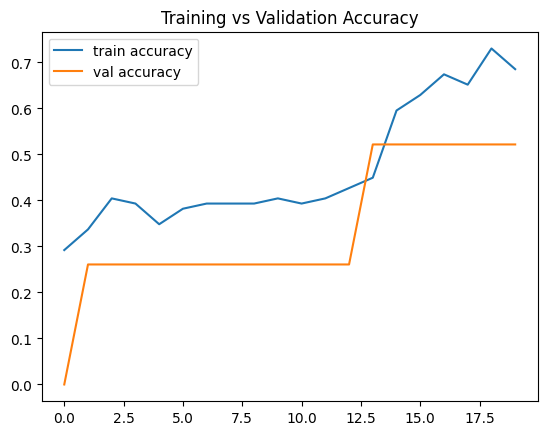

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()